# 229. Majority Element II
https://leetcode.com/problems/majority-element-ii/

## Complexity Comparison

| Approach | Time | Space | Notes |
|----------|------|-------|-------|
| Boyer-Moore Voting (extended) | $O(n)$ | $O(1)$ | Optimal — at most 2 candidates |
| Hash map counting | $O(n)$ | $O(n)$ | Count all occurrences |
| Sort | $O(n \log n)$ | $O(1)$ | Sort then scan |

## Methodology

At most two elements can appear more than n/3 times. Use the extended Boyer-Moore Voting algorithm with two candidates and two counters. First pass: find the two candidates. Second pass: verify each candidate actually appears more than n/3 times.

## Solutions

### C#

In [ ]:
public class Solution {
    public IList<int> MajorityElement(int[] nums) {
        int cand1 = 0, cand2 = 0, count1 = 0, count2 = 0;
        foreach (int num in nums) {
            if (num == cand1) count1++;
            else if (num == cand2) count2++;
            else if (count1 == 0) { cand1 = num; count1 = 1; }
            else if (count2 == 0) { cand2 = num; count2 = 1; }
            else { count1--; count2--; }
        }
        var result = new List<int>();
        count1 = count2 = 0;
        foreach (int num in nums) {
            if (num == cand1) count1++;
            else if (num == cand2) count2++;
        }
        if (count1 > nums.Length / 3) result.Add(cand1);
        if (count2 > nums.Length / 3) result.Add(cand2);
        return result;
    }
}

### Python

In [ ]:
class Solution:
    def majorityElement(self, nums: list[int]) -> list[int]:
        cand1 = cand2 = 0
        count1 = count2 = 0
        for num in nums:
            if num == cand1:
                count1 += 1
            elif num == cand2:
                count2 += 1
            elif count1 == 0:
                cand1, count1 = num, 1
            elif count2 == 0:
                cand2, count2 = num, 1
            else:
                count1 -= 1
                count2 -= 1
        threshold = len(nums) // 3
        return [c for c in (cand1, cand2) if nums.count(c) > threshold and c == cand1 or nums.count(c) > threshold and c == cand2]

### Go

In [ ]:
func majorityElement(nums []int) []int {
    cand1, cand2, count1, count2 := 0, 0, 0, 0
    for _, num := range nums {
        if num == cand1 {
            count1++
        } else if num == cand2 {
            count2++
        } else if count1 == 0 {
            cand1, count1 = num, 1
        } else if count2 == 0 {
            cand2, count2 = num, 1
        } else {
            count1--
            count2--
        }
    }
    count1, count2 = 0, 0
    for _, num := range nums {
        if num == cand1 {
            count1++
        } else if num == cand2 {
            count2++
        }
    }
    var result []int
    if count1 > len(nums)/3 {
        result = append(result, cand1)
    }
    if count2 > len(nums)/3 {
        result = append(result, cand2)
    }
    return result
}

### Rust

In [ ]:
impl Solution {
    pub fn majority_element(nums: Vec<i32>) -> Vec<i32> {
        let (mut c1, mut c2) = (0, 0);
        let (mut cnt1, mut cnt2) = (0i32, 0i32);
        for &num in &nums {
            if num == c1 { cnt1 += 1; }
            else if num == c2 { cnt2 += 1; }
            else if cnt1 == 0 { c1 = num; cnt1 = 1; }
            else if cnt2 == 0 { c2 = num; cnt2 = 1; }
            else { cnt1 -= 1; cnt2 -= 1; }
        }
        let threshold = nums.len() as i32 / 3;
        let mut result = Vec::new();
        if nums.iter().filter(|&&x| x == c1).count() as i32 > threshold {
            result.push(c1);
        }
        if c1 != c2 && nums.iter().filter(|&&x| x == c2).count() as i32 > threshold {
            result.push(c2);
        }
        result
    }
}

## Example Scenarios

1. **Common Case** — One majority element  
   **Input:** `nums = [3,2,3]`  
   Element $3$ appears $2$ times out of $3$. Since $2 > \lfloor 3/3 \rfloor = 1$, it qualifies. Element $2$ appears only once, so output is $[3]$.

2. **Slightly Complex** — Two majority elements  
   **Input:** `nums = [1,2,1,2,1,2,3]`  
   Length $n=7$, threshold $\lfloor 7/3 \rfloor = 2$. Element $1$ appears $3$ times and $2$ appears $3$ times — both $> 2$. Element $3$ appears once. Boyer-Moore finds candidates $1$ and $2$, verification confirms both. Output: $[1,2]$.

3. **Edge Case: Time Factor** — Array of $5 \times 10^4$ elements, no majority  
   **Input:** `nums = [1,2,3,1,2,3,...,1,2,3,4]` (repeating triplet + extra)  
   Two full passes over $n = 50000$ elements: first pass finds two candidates via Boyer-Moore voting, second pass counts them. Neither exceeds $\lfloor 50000/3 \rfloor$. Output: $[]$. Exercises worst-case $O(n)$ time with empty result.

4. **Edge Case: Space Factor** — All identical elements  
   **Input:** `nums = [7,7,7,7,7]`  
   Candidate 1 locks to $7$ immediately, count never drops. Only one candidate slot is used. The algorithm's $O(1)$ extra space is at its minimum — just two candidate/count pairs. Output: $[7]$.

5. **Almost-Impossible but Plausible** — Exactly at the $\lfloor n/3 \rfloor$ boundary  
   **Input:** `nums = [1,1,2,2,3,3]`  
   Length $n=6$, threshold $\lfloor 6/3 \rfloor = 2$. Each element appears exactly $2$ times. Since the condition is strictly $> \lfloor n/3 \rfloor$ (not $\ge$), no element qualifies. Output: $[]$. Tests the off-by-one boundary precisely.

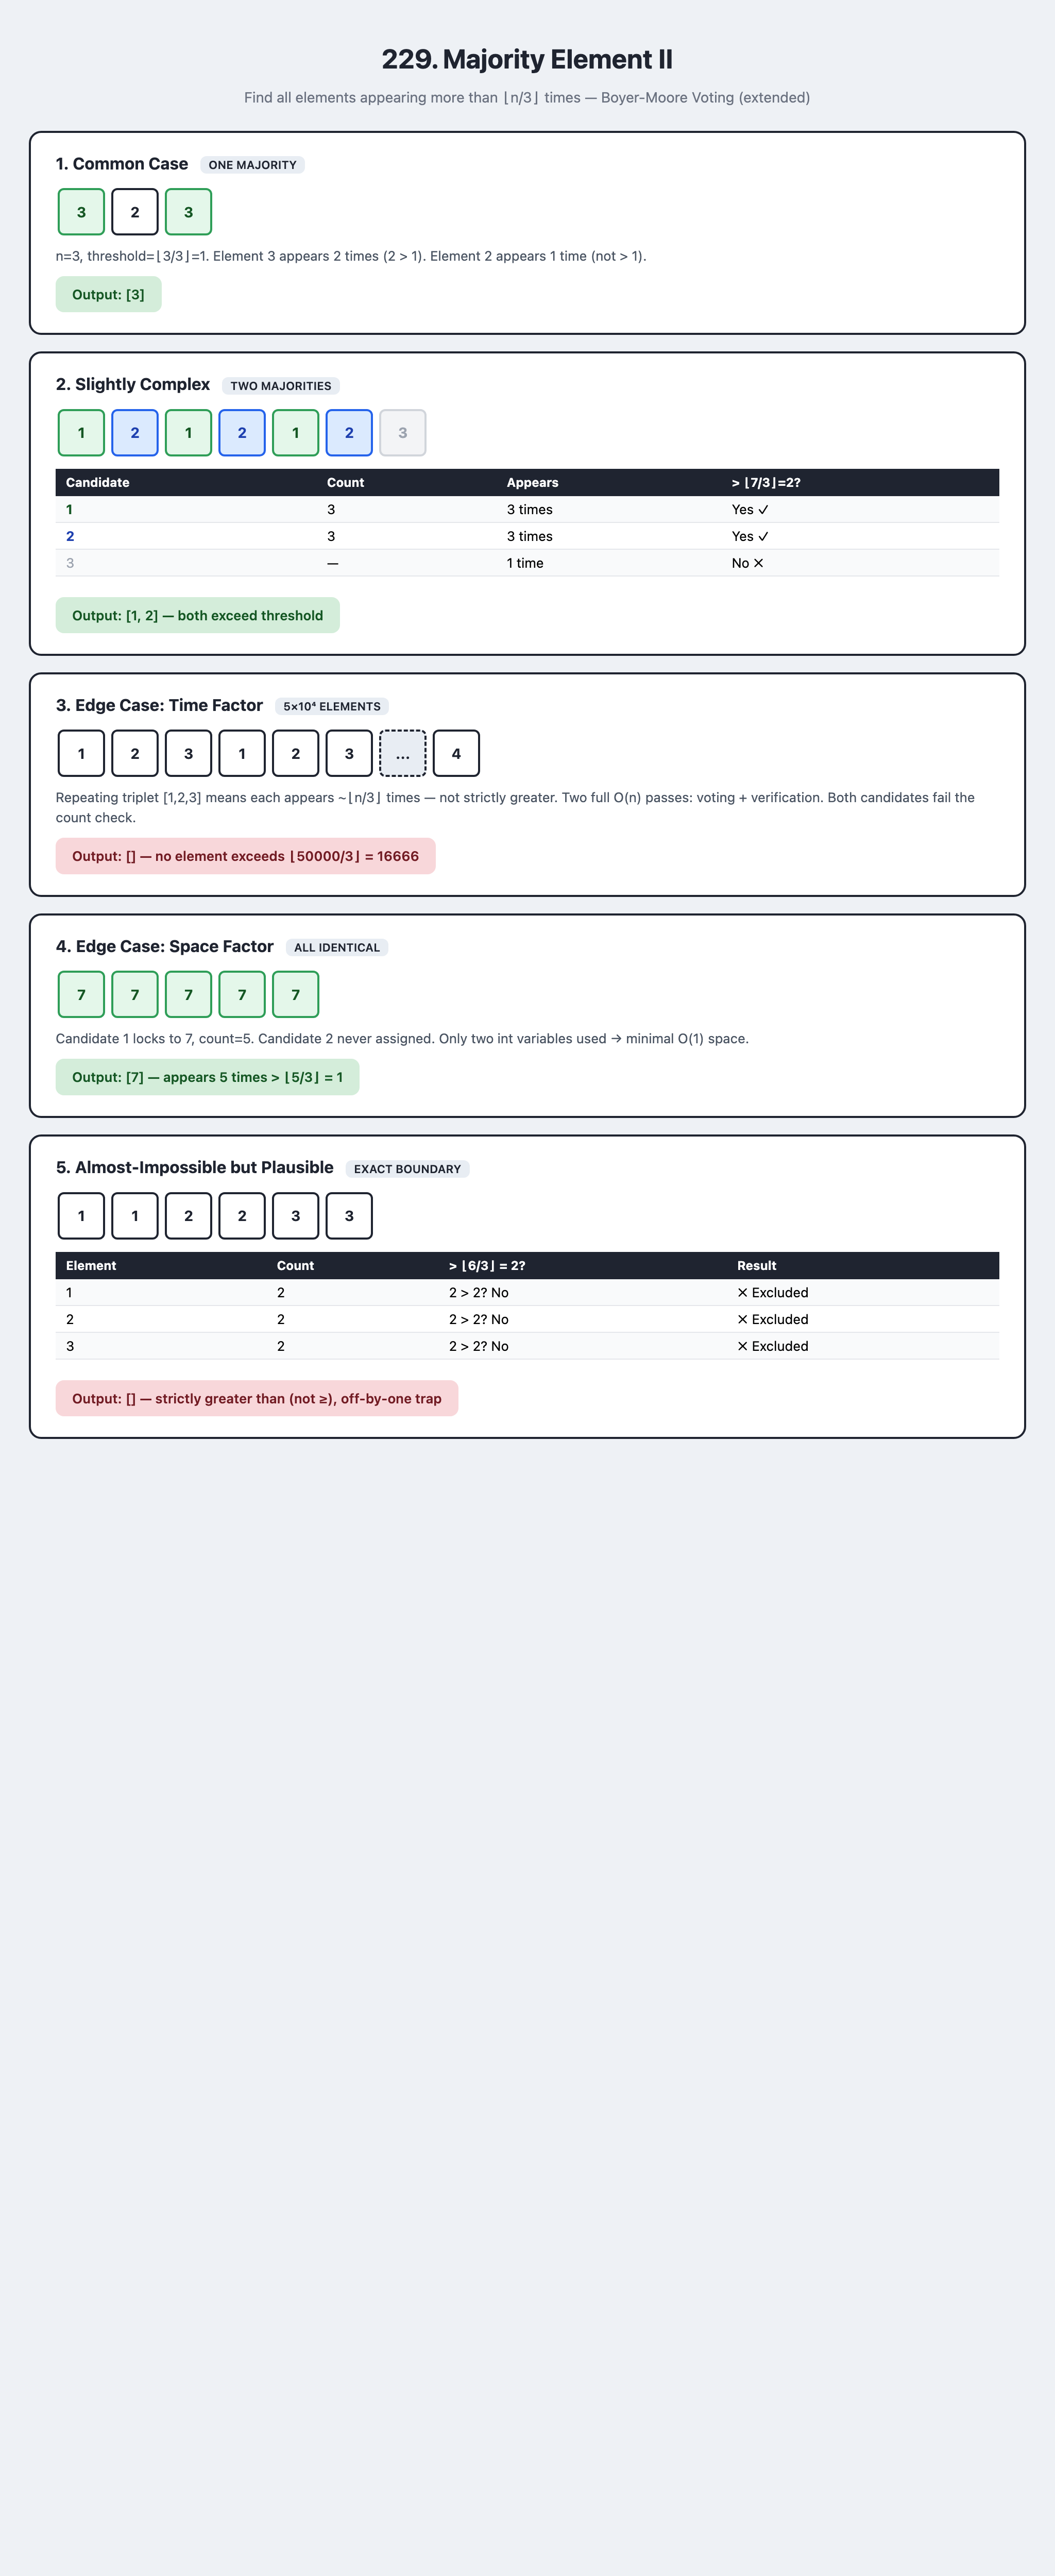